## IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from gensim.models import KeyedVectors
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import gensim.downloader as api

c:\Users\maria\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


## LIMPIEZA DE LOS DATOS

Realizamos una limpieza de los datos para eliminar factores que podrían sesgar al modelo y hacer que aprenda por razones incorrectas. Por ejemplo, observamos que la mayoría de las noticias reales comienzan de forma similar, lo cual podría influir indebidamente en la clasificación. También decidimos no incluir el título como variable de entrada, ya que durante las pruebas notamos que las noticias falsas solían seguir un formato muy específico. Incluso al generar una noticia sin ese formato, el modelo tendía a clasificarla como real. Algo similar ocurre con la variable subject, ya que ciertos temas aparecen casi exclusivamente en noticias reales y otros en noticias falsas. Esto podría llevar al modelo a tomar decisiones basadas en el tema más que en el contenido. Nuestro objetivo es que el modelo aprenda a diferenciar noticias reales de falsas a partir del contenido, sin dejarse influenciar por patrones superficiales.

In [2]:
df_true = pd.read_csv('data/True.csv')
df_fake = pd.read_csv('data/Fake.csv')

df_true['output'] = 'True'
df_fake['output'] = 'Fake'
df_true['text'] = df_true['text'].str.replace(r'^[^–\-]+[–\-]\s*', '', regex=True).str.lstrip()
df_true['title'] = df_true['title'].str.lstrip()
df_fake['title'] = df_fake['title'].str.lstrip()
df_fake['text'] = df_fake['text'].str.lstrip()

In [3]:
data = pd.concat([df_true, df_fake], ignore_index=True)
data.drop_duplicates()
data.head()

,title,text,subject,date,output
0,"As U.S. budget fight looms, Republicans flip t...",The head of a conservative Republican faction ...,politicsNews,"December 31, 2017",True
1,U.S. military to accept transgender recruits o...,Transgender people will be allowed for the fir...,politicsNews,"December 29, 2017",True
2,Senior U.S. Republican senator: 'Let Mr. Muell...,The special counsel investigation of links bet...,politicsNews,"December 31, 2017",True
3,FBI Russia probe helped by Australian diplomat...,Trump campaign adviser George Papadopoulos tol...,politicsNews,"December 30, 2017",True
4,Trump wants Postal Service to charge 'much mor...,President Donald Trump called on the U.S. Post...,politicsNews,"December 29, 2017",True


In [ ]:
# Extraer variables
X1 = data['title'].astype(str)
y = np.array(data['output'])

## VECTORIZAR

Primero, se crea un tokenizador que solo considera las 10,000 palabras más frecuentes. Luego, se ajusta a los textos para aprender el vocabulario y convertir cada texto en una secuencia de números (cada número representa una palabra). Finalmente, se aplica padding para que todas las secuencias tengan la misma longitud (5000 palabras), rellenando con ceros las más cortas. 

In [ ]:
# Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X1 )

# Secuencias numéricas
sequences1 = tokenizer.texts_to_sequences(X1)

# Padding
max_len = 5000
X1_padded = pad_sequences(sequences1, maxlen=max_len)


Luego, dividimos el conjunto de datos en entrenamiento, validación y prueba para entrenar el modelo correctamente para poder verificar que no haya overfitting. Además, transformamos la variable de salida (y) a formato binario: asignando 0 a las noticias falsas ('fake') y 1 a las verdaderas ('true').

In [10]:
# Dividir
X1_train, X1_val, y_train, y_val = train_test_split(
    X1_padded, y, test_size=0.25, random_state=42)

# Convertir y a binario
y_train = np.where(y_train == "Fake", 0, 1).astype(np.float32)
y_val = np.where(y_val == "Fake", 0, 1).astype(np.float32)

Se carga un modelo de Word2Vec preentrenado (Google News, 300 dimensiones) usando Gensim para representar cada palabra como un vector que refleja su significado. Esto permite al modelo entender mejor el contenido del texto, ya que palabras con contextos similares tendrán vectores similares. Luego, se construye una embedding matrix con los vectores del vocabulario. Si una palabra no está en el modelo, se le asigna un vector aleatorio. Finalmente, se crea una capa Embedding con estos pesos preentrenados (no entrenables), aprovechando representaciones semánticas ya aprendidas para mejorar la clasificación de noticias.

In [11]:
# Carga automática del modelo preentrenado desde gensim
w2v_model = api.load("word2vec-google-news-300")

In [ ]:
# Crear embedding matrix
embedding_dim = 300
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
    else:
        embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)

# Capa embedding con pesos preentrenados
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False)

## ENTRENAR MODELO

Se construye un modelo secuencial con una arquitectura simple basada en una capa SimpleRNN de 64 unidades que recibe como entrada las secuencias de texto ya vectorizadas a través de la capa Embedding. Luego, se añade una capa densa con activación ReLU y regularización L2 para evitar sobreajuste, seguida de una capa de salida con activación sigmoide para clasificar las noticias como reales (1) o falsas (0).
El modelo se compila con el optimizador Adam y la función de pérdida binary_crossentropy, adecuada para clasificación binaria.
También se configuran dos callbacks:

- EarlyStopping para detener el entrenamiento si la pérdida de validación no mejora en 2 épocas.

- ModelCheckpoint para guardar automáticamente el mejor modelo durante el entrenamiento.

In [13]:
# Modelo
input1 = Input(shape=(max_len,))
embedding1 = embedding_layer(input1)
rnn1 = SimpleRNN(64)(embedding1)

dense1 = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(rnn1)
output = Dense(1, activation="sigmoid")(dense1)

model = Model(inputs=input1, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1)

checkpoint = ModelCheckpoint(
    'modelo_RNN_Word2Vec.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 5000, 300)      │     9,540,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate (Concatenate)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,568,485 (36.50 MB)

 Trainable params: 27,585 (107.75 KB)

 Non-trainable params: 9,540,900 (36.40 MB)

In [14]:
# Entrenamiento
history = model.fit(
    [X1_train],
    y_train,
    epochs=10,
    batch_size=256,
    validation_data=([X1_val], y_val),
    callbacks=[early_stop, checkpoint],
    verbose=2)

Epoch 1/10

Epoch 1: val_loss improved from inf to 0.30097, saving model to modelo_RNN_Word2Vec.keras
132/132 - 306s - 2s/step - accuracy: 0.8120 - loss: 0.4958 - val_accuracy: 0.9074 - val_loss: 0.3010
Epoch 2/10

Epoch 2: val_loss improved from 0.30097 to 0.25189, saving model to modelo_RNN_Word2Vec.keras
132/132 - 411s - 3s/step - accuracy: 0.9114 - loss: 0.2692 - val_accuracy: 0.9161 - val_loss: 0.2519
Epoch 3/10

Epoch 3: val_loss did not improve from 0.25189
132/132 - 414s - 3s/step - accuracy: 0.9173 - loss: 0.2472 - val_accuracy: 0.9091 - val_loss: 0.2678
Epoch 4/10

Epoch 4: val_loss did not improve from 0.25189
132/132 - 413s - 3s/step - accuracy: 0.9008 - loss: 0.2812 - val_accuracy: 0.7462 - val_loss: 0.5092
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


In [15]:
results = model.evaluate([X1_val], y_val)
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 294ms/step - accuracy: 0.9155 - loss: 0.2500
Test Loss: 0.25189268589019775, Test Accuracy: 0.9160801768302917


Observamos que el modelo entrenado alcanza un accuracy del 91,14 % en el conjunto de entrenamiento y del 91,61 % en validación. Además, al evaluarlo con el conjunto de prueba, obtiene un accuracy del 91,60 %. Estos resultados son consistentes entre sí, lo que indica que el modelo no presenta overfitting y, en general, clasifica correctamente las noticias reales y falsas.

## VISUALIZAR RESULTADOS

La gráfica muestra que el modelo mejora en las primeras épocas, pero a partir de la tercera comienza a sobreajustarse, ya que la pérdida de validación aumenta mientras la de entrenamiento sigue bajando. Gracias al early stopping, se detuvo el entrenamiento a tiempo, evitando el overfitting.

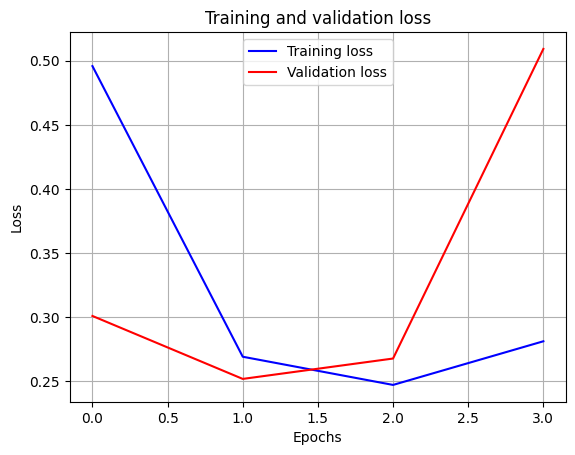

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color='blue', label='Training loss')
plt.plot(history.history['val_loss'], color='red', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

En la gráfica de accuracy podemos visualizar los mismos resultados que en la de perdida

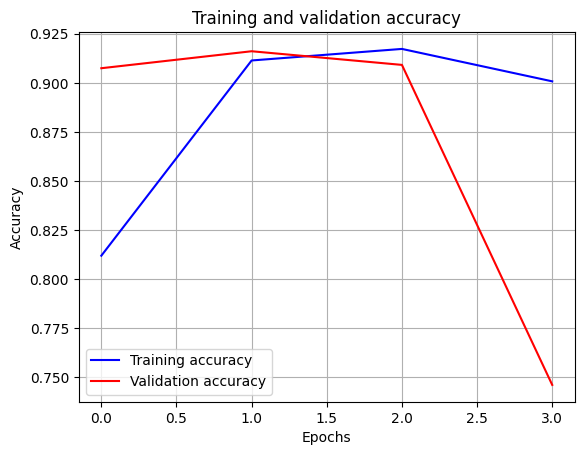

In [17]:
plt.plot(history.history['accuracy'], color='blue', label='Training accuracy')
plt.plot(history.history['val_accuracy'], color='red', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los casos, con pocos errores en ambas clases. Tiene una ligera tendencia a confundir noticias reales con falsas, pero en general su rendimiento es sólido y equilibrado.

351/351 ━━━━━━━━━━━━━━━━━━━━ 116s 330ms/step


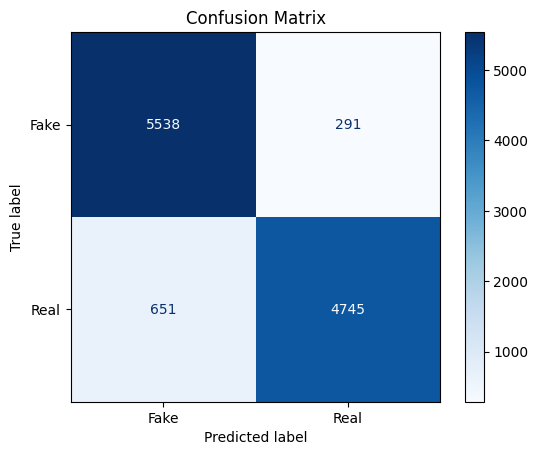

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
y_pred_prob = model.predict([X1_val])
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

La curva ROC muestra que el modelo tiene una alta capacidad de discriminación entre clases, con un AUC de 0.98, muy cercano al valor ideal de 1. Esto indica que el modelo clasifica de forma muy precisa, superando la predicción aleatoria.

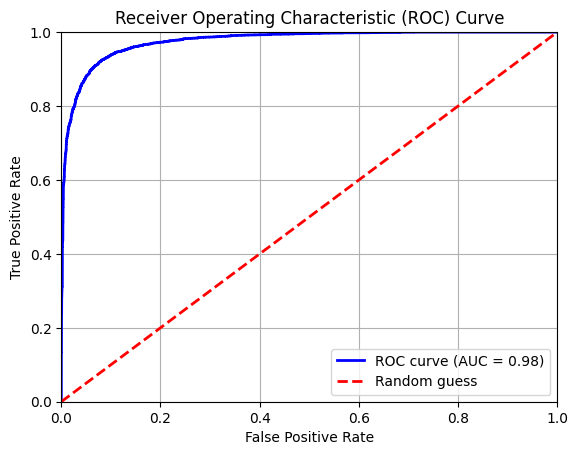

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
auc_score = roc_auc_score(y_val, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## COMPROBACION DEL MODELO

En esta sección ponemos a prueba el modelo con una noticia real tomada de la web reuters y una falsa generada artificialmente. El modelo logra clasificarlas correctamente, aunque muestra mayor seguridad al identificar la falsa. Esto demuestra que el modelo generaliza bien y es capaz de detectar noticias falsas con alta confianza.

In [20]:

fake_body = (
    "In a bizarre twist straight out of a science fiction movie, an anonymous source has leaked classified documents "
    "allegedly revealing the existence of an alien base located beneath the Eiffel Tower in Paris. The source claims that "
    "during a routine maintenance check in early 2023, underground scanners picked up unexplained electromagnetic activity "
    "that led to the discovery of a hidden chamber. Inside, maintenance workers allegedly found strange equipment, symbols "
    "not of any known language, and even signs of biological organisms that emit light. The beings, reportedly resembling "
    "tall humanoid figures with elongated limbs, are said to have been living undetected for decades and use advanced "
    "technology to avoid human detection. Despite repeated inquiries from journalists and independent researchers, French "
    "government officials have refused to comment on the matter. Conspiracy theorists argue that world governments have "
    "known about extraterrestrial life for years and are now working together to suppress this new revelation. No physical "
    "evidence has yet been presented to the public, and mainstream scientists have dismissed the claims as a hoax. However, "
    "online forums and social media are buzzing with speculation, and some Parisians have reported unusual activity near the landmark at night."
)


In [38]:

true_body = (
    "Steve Bannon, a former top White House strategist and a former chief campaign aide to Donald Trump, "
    "has been asked to testify before the U.S. House of Representatives intelligence panel next month, Bloomberg News reported. "
    "Corey Lewandowski, Trump’s former campaign manager, was also asked to testify in early January, Bloomberg reported on Friday, "
    "citing an official familiar with the committee’s schedule. "
    "Representatives for the committee did not immediately respond to inquiries for comment. "
    "The panel is probing alleged Russian meddling into the 2016 U.S. election."
)





In [39]:
def predict_news(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    prob = model.predict(padded)[0][0]
    label = "Real" if prob > 0.5 else "Fake"
    print(f"Predicted: {label} (Probability: {prob:.4f})")
predict_news(true_body)
predict_news(fake_body)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted: Real (Probability: 0.6589)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Predicted: Fake (Probability: 0.1604)
